In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
df = pd.read_csv('/DataSet.csv')
df.head()

,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,NaN,0,Same Day,1,Yes,Cash on Delivery,4,Not Returned,0,Fortnightly
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,NaN,Clothing,Shirt,...,NaN,0,NaN,0,No,UPI,5,Not Returned,0,Fortnightly
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,NaN,0,Standard,7,Yes,UPI,3,Not Returned,0,Rarely
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,NaN,0,Standard,6,Yes,Net Banking,4,Not Returned,0,Fortnightly
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,NaN,99,Express,2,No,Debit Card,4,Not Returned,0,Weekly


In [32]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (10000, 26)


In [62]:
# Display column names
print(df.columns.tolist())

['Transaction ID', 'Customer ID', 'Purchase Date', 'Age', 'Gender', 'Location', 'Online/Offline', 'Online Store', 'Category', 'Item Purchased', 'Brand', 'Color', 'Size', 'Quantity', 'Purchase Amount (₹)', 'Discount (%)', 'Festival/Sale', 'Shipping Charge (₹)', 'Delivery Speed', 'Delivery Time (Days)', 'Subscription Status', 'Payment Method', 'Review Rating', 'Return Status', 'Previous Purchases', 'Frequency of Purchases']


In [34]:
print(df.dtypes)

Transaction ID            object
Customer ID               object
Purchase Date             object
Age                        int64
Gender                    object
Location                  object
Online/Offline            object
Online Store              object
Category                  object
Item Purchased            object
Brand                     object
Color                     object
Size                      object
Quantity                   int64
Purchase Amount (₹)        int64
Discount (%)               int64
Festival/Sale             object
Shipping Charge (₹)        int64
Delivery Speed            object
Delivery Time (Days)       int64
Subscription Status       object
Payment Method            object
Review Rating              int64
Return Status             object
Previous Purchases         int64
Frequency of Purchases    object
dtype: object


In [35]:
# Check missing values
print(df.isnull().sum())

Transaction ID               0
Customer ID                  0
Purchase Date                0
Age                          0
Gender                       0
Location                     0
Online/Offline               0
Online Store              2249
Category                     0
Item Purchased               0
Brand                        0
Color                        0
Size                      1035
Quantity                     0
Purchase Amount (₹)          0
Discount (%)                 0
Festival/Sale             6788
Shipping Charge (₹)          0
Delivery Speed            2249
Delivery Time (Days)         0
Subscription Status          0
Payment Method               0
Review Rating                0
Return Status                0
Previous Purchases           0
Frequency of Purchases       0
dtype: int64


In [36]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [37]:
# Make a copy of the original dataset
df_clean = df.copy()

In [38]:
# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

In [39]:
# Check for duplicate column names
print("Duplicate columns:")
print(df_clean.columns[df_clean.columns.duplicated()].tolist())

Duplicate columns:
[]


In [40]:
# Convert Purchase Date to datetime format
df_clean['Purchase Date'] = pd.to_datetime(
    df_clean['Purchase Date'],

)

df_clean['Online Store'] = df_clean['Online Store'].fillna('Not Applicable')
df_clean['Delivery Speed'] = df_clean['Delivery Speed'].fillna('Not Applicable')
df_clean['Festival/Sale'] = df_clean['Festival/Sale'].fillna('No Sale')
df_clean['Size'] = df_clean['Size'].fillna('Not Applicable')

df_clean.isnull().sum()

,0
Transaction ID,0
Customer ID,0
Purchase Date,0
Age,0
Gender,0
Location,0
Online/Offline,0
Online Store,0
Category,0
Item Purchased,0


In [41]:
# Check the cleaned dataset
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows after cleaning:")
print(df_clean.duplicated().sum())

df_clean.head()

Original shape: (10000, 26)
Cleaned shape: (10000, 26)

Remaining missing values:
0

Duplicate rows after cleaning:
0


,Transaction ID,Customer ID,Purchase Date,Age,Gender,Location,Online/Offline,Online Store,Category,Item Purchased,...,Festival/Sale,Shipping Charge (₹),Delivery Speed,Delivery Time (Days),Subscription Status,Payment Method,Review Rating,Return Status,Previous Purchases,Frequency of Purchases
0,TXN507808,CUST102534,2023-01-01,51,Male,Chennai,Online,Flipkart,Clothing,Kurta,...,No Sale,0,Same Day,1,Yes,Cash on Delivery,4,Not Returned,0,Fortnightly
1,TXN503830,CUST101256,2023-01-01,27,Female,Mumbai,Offline,Not Applicable,Clothing,Shirt,...,No Sale,0,Not Applicable,0,No,UPI,5,Not Returned,0,Fortnightly
2,TXN501496,CUST100490,2023-01-01,57,Male,Hyderabad,Online,Flipkart,Clothing,Jacket,...,No Sale,0,Standard,7,Yes,UPI,3,Not Returned,0,Rarely
3,TXN501538,CUST100500,2023-01-01,22,Female,Pune,Online,Myntra,Clothing,Kurta,...,No Sale,0,Standard,6,Yes,Net Banking,4,Not Returned,0,Fortnightly
4,TXN504265,CUST101399,2023-01-01,30,Male,Visakhapatnam,Online,Myntra,Accessories,Cap,...,No Sale,99,Express,2,No,Debit Card,4,Not Returned,0,Weekly


In [43]:
# Fill missing numerical values with the median
numeric_cols = df_clean.select_dtypes(include=np.number).columns

In [44]:
# Descriptive statistics
print("Statistical Summary:")
display(df_clean[numeric_cols].describe())

Statistical Summary:


,Age,Quantity,Purchase Amount (₹),Discount (%),Shipping Charge (₹),Delivery Time (Days),Review Rating,Previous Purchases
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,38.278100,1.425100,1889.882000,32.916300,41.49210,3.703600,3.874900,3.211400
std,12.133041,0.761346,2102.301836,21.440617,64.30923,2.726223,0.912871,3.951313
min,18.000000,1.000000,67.000000,0.000000,0.00000,0.000000,1.000000,0.000000
25%,28.000000,1.000000,600.000000,12.000000,0.00000,1.000000,3.000000,0.000000
50%,38.000000,1.000000,1207.000000,33.000000,0.00000,4.000000,4.000000,2.000000
75%,49.000000,2.000000,2376.000000,52.000000,79.00000,6.000000,5.000000,4.000000
max,59.000000,4.000000,22306.000000,70.000000,199.00000,8.000000,5.000000,28.000000


In [45]:
# Mean
print("\nMean:")
display(df_clean[numeric_cols].mean())


Mean:


,0
Age,38.2781
Quantity,1.4251
Purchase Amount (₹),1889.8820
Discount (%),32.9163
Shipping Charge (₹),41.4921
Delivery Time (Days),3.7036
Review Rating,3.8749
Previous Purchases,3.2114


In [46]:
# Median
print("\nMedian:")
display(df_clean[numeric_cols].median())


Median:


,0
Age,38.0
Quantity,1.0
Purchase Amount (₹),1207.0
Discount (%),33.0
Shipping Charge (₹),0.0
Delivery Time (Days),4.0
Review Rating,4.0
Previous Purchases,2.0


In [47]:
# Standard Deviation
print("\nStandard Deviation:")
display(df_clean[numeric_cols].std())


Standard Deviation:


,0
Age,12.133041
Quantity,0.761346
Purchase Amount (₹),2102.301836
Discount (%),21.440617
Shipping Charge (₹),64.309230
Delivery Time (Days),2.726223
Review Rating,0.912871
Previous Purchases,3.951313


In [48]:
# Correlation with Purchase Amount
target = 'Purchase Amount (₹)'
correlation = df_clean[numeric_cols].corr()
print("\nCorrelation with Purchase Amount:")
display(correlation[target].sort_values(ascending=False))


Correlation with Purchase Amount:


,Purchase Amount (₹)
Purchase Amount (₹),1.000000
Quantity,0.504029
Discount (%),0.164880
Previous Purchases,0.006607
Review Rating,0.005195
Delivery Time (Days),-0.008028
Age,-0.012056
Shipping Charge (₹),-0.088223


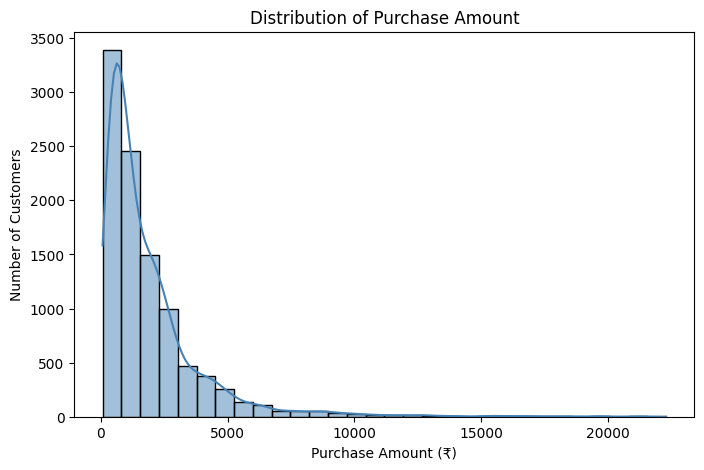

In [49]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['Purchase Amount (₹)'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount (₹)')
plt.ylabel('Number of Customers')
plt.show()

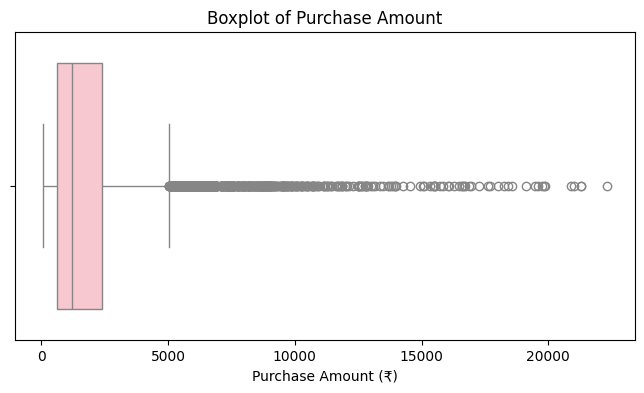

In [50]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['Purchase Amount (₹)'], color='pink')
plt.title('Boxplot of Purchase Amount')
plt.show()

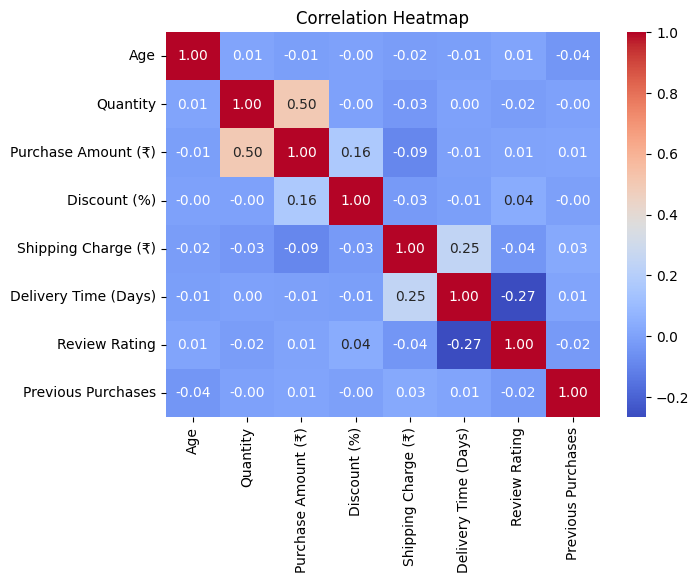

In [51]:
plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

features = ['Age', 'Gender', 'Category', 'Online/Offline', 'Quantity',
            'Discount (%)', 'Shipping Charge (₹)', 'Delivery Time (Days)',
            'Payment Method', 'Review Rating', 'Previous Purchases']

X = df_clean[features]
y = df_clean['Purchase Amount (₹)']

# Convert categorical columns into 0/1 dummy columns
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (8000, 17)
Test size: (2000, 17)


In [53]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [54]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODEL EVALUATION")
print("----------------------------")
print(f"MAE:  ₹{mae:.2f}")
print(f"RMSE: ₹{rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MODEL EVALUATION
----------------------------
MAE:  ₹1118.05
RMSE: ₹1639.53
R² Score: 0.3683


In [55]:
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Baseline RMSE (predicting the mean every time): ₹{baseline_rmse:.2f}")
print(f"Model RMSE: ₹{rmse:.2f}")

Baseline RMSE (predicting the mean every time): ₹2063.53
Model RMSE: ₹1639.53


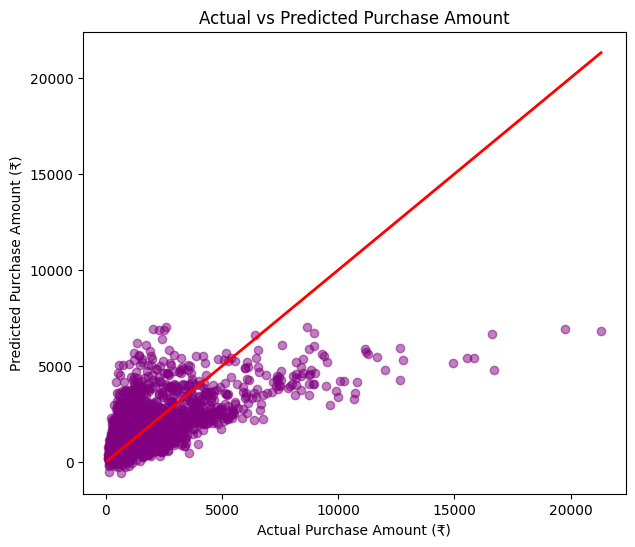

In [56]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.xlabel('Actual Purchase Amount (₹)')
plt.ylabel('Predicted Purchase Amount (₹)')
plt.title('Actual vs Predicted Purchase Amount')
plt.show()